---
##  STEP 0 — Setting Up Our Lab Environment

**What are we doing here?**
Before we start any experiment in a real lab, we set up our equipment. In programming, this means importing all the **libraries** (ready-made tools) we'll need throughout the lab.

- `pandas` → for loading and managing data tables (like Excel)
- `numpy` → for math and number crunching
- `matplotlib` & `seaborn` → for drawing charts and graphs
- `sklearn` → the main machine learning library — gives us Decision Trees, splitting tools, and evaluation metrics

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pandas", "numpy", "scikit-learn",
                "matplotlib", "seaborn", "-q"])
print(" Packages ready!")

 Packages ready!



## Lab  Classification with Decision Trees
**Instructor:** Engr. Saad Mazhar Khan | **Department:** Software Engineering, Bahria University Islamabad

---

### What Will We Do in This Lab?

We will follow the **exact same steps** a data scientist follows in a real project:

| Step | What We Do | Why It Matters |
|------|-----------|----------------|
| 1 | Load Dataset | Get the raw data |
| 2 | Explore Data (EDA) | Understand what we're working with |
| 3 | Feature Selection | Pick only the most useful attributes |
| 4 | Feature Extraction (PCA) | Create new compressed features |
| 5 | Entropy & Info Gain | Understand how the tree decides to split |
| 6 | Train/Test Split | Separate data for learning and evaluation |
| 7 | Build Full Tree | Train the classifier |
| 8 | Pruning | Fix overfitting |
| 9 | Evaluate | Measure how good our model is |
| 10 | Compare | Full vs Pruned vs Baseline |
| 11 | Predict | Use model on brand new data |

###  Dataset: Cleveland Heart Disease Dataset
We will predict whether a patient has **heart disease (Yes/No)** based on clinical measurements.

| Feature | Description | Type |
|---------|-------------|------|
| age | Age in years | Continuous |
| sex | Sex (1=Male, 0=Female) | Categorical |
| cp | Chest pain type (0–3) | Categorical |
| trestbps | Resting blood pressure | Continuous |
| chol | Serum cholesterol (mg/dl) | Continuous |
| fbs | Fasting blood sugar > 120? (1=Yes) | Categorical |
| restecg | Resting ECG results (0–2) | Categorical |
| thalach | Max heart rate achieved | Continuous |
| exang | Exercise induced angina (1=Yes) | Categorical |
| oldpeak | ST depression induced by exercise | Continuous |
| slope | Slope of peak exercise ST segment | Categorical |
| ca | Number of major vessels colored | Continuous |
| thal | Thalassemia type (1,2,3) | Categorical |
| **target** | **1 = Heart Disease, 0 = No Heart Disease (CLASS)** | **Class** |

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning — Decision Tree
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# Machine Learning — Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Machine Learning — Feature Selection
from sklearn.feature_selection import mutual_info_classif

# Machine Learning — Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Suppress minor warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# Make all our charts look clean and consistent
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("All imports successful — ready to begin!")

All imports successful — ready to begin!


---
##  STEP 1 — Loading the Dataset

**What are we doing here?**
Every machine learning project starts with data. We load the **Cleveland Heart Disease dataset** a real dataset used in medical research. It contains records of 303 patients, each described by 13 clinical features and a class label (heart disease: yes or no).

We load it as a **CSV file** (Comma-Separated Values) — the most common format for structured datasets. Think of it as an Excel sheet saved as plain text.

- If internet is available → downloads directly from UCI repository
- If offline → creates a realistic sample dataset automatically

In [ ]:
column_names = [
    'age',        # Age of the patient (years)
    'sex',        # Sex: 1 = Male, 0 = Female
    'cp',         # Chest pain type: 0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic
    'trestbps',   # Resting blood pressure (mm Hg)
    'chol',       # Serum cholesterol (mg/dl)
    'fbs',        # Fasting blood sugar > 120 mg/dl: 1=True, 0=False
    'restecg',    # Resting ECG results: 0=normal, 1=ST-T abnormality, 2=left ventricular hypertrophy
    'thalach',    # Maximum heart rate achieved
    'exang',      # Exercise induced angina: 1=Yes, 0=No
    'oldpeak',    # ST depression induced by exercise relative to rest
    'slope',      # Slope of peak exercise ST segment: 0=upsloping, 1=flat, 2=downsloping
    'ca',         # Number of major vessels colored by fluoroscopy (0–3)
    'thal',       # Thalassemia: 1=normal, 2=fixed defect, 3=reversable defect
    'target'      # CLASS LABEL: 0 = No Heart Disease, 1 = Heart Disease
]

#  Try loading from UCI repository (original source)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

try:
    df = pd.read_csv(url, header=None, names=column_names, na_values='?')
    print("Dataset loaded from UCI repository!")
except Exception:
    # Fallback: Try the Kaggle mirror
    try:
        mirror = "https://raw.githubusercontent.com/rashida048/Datasets/master/heart.csv"
        df = pd.read_csv(mirror)
        # Rename target column to match our naming
        if 'target' not in df.columns and 'output' in df.columns:
            df.rename(columns={'output': 'target'}, inplace=True)
        print("Dataset loaded from mirror!")
    except Exception:
        # Offline fallback: generate realistic sample data
        print("No internet. Generating realistic sample data...")
        np.random.seed(42)
        n = 303
        df = pd.DataFrame({
            'age':      np.random.randint(29, 77, n),
            'sex':      np.random.choice([0, 1], n, p=[0.32, 0.68]),
            'cp':       np.random.choice([0, 1, 2, 3], n),
            'trestbps': np.random.randint(94, 200, n),
            'chol':     np.random.randint(126, 564, n),
            'fbs':      np.random.choice([0, 1], n, p=[0.85, 0.15]),
            'restecg':  np.random.choice([0, 1, 2], n, p=[0.48, 0.49, 0.03]),
            'thalach':  np.random.randint(71, 202, n),
            'exang':    np.random.choice([0, 1], n, p=[0.67, 0.33]),
            'oldpeak':  np.round(np.random.uniform(0, 6.2, n), 1),
            'slope':    np.random.choice([0, 1, 2], n),
            'ca':       np.random.choice([0, 1, 2, 3], n, p=[0.58, 0.22, 0.13, 0.07]),
            'thal':     np.random.choice([1, 2, 3], n, p=[0.18, 0.55, 0.27]),
            'target':   np.random.choice([0, 1], n, p=[0.46, 0.54])
        })
        print("Sample dataset created!")

#  Handle the original dataset where target has values 0–4
#  In medical literature: 0 = no disease, 1-4 = disease present
#  We convert to binary: 0 = No Disease, 1 = Disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Drop rows with missing values (very few in this dataset)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\n Dataset shape : {df.shape[0]} patients × {df.shape[1]} columns")
print(f"   Features       : {df.shape[1] - 1}")
print(f"   Class labels   : target (0 = No Disease, 1 = Heart Disease)")
print("\n First 8 rows of the dataset:")
df.head(8)

Dataset loaded from UCI repository!

 Dataset shape : 297 patients × 14 columns
   Features       : 13
   Class labels   : target (0 = No Disease, 1 = Heart Disease)

 First 8 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0


---
##  STEP 2 — Exploratory Data Analysis (EDA)

**What are we doing here?**
Before building any model, we must **understand our data deeply**. Think of this like a doctor reviewing a patient's history before making a diagnosis. We will:

1. Check **basic statistics** (min, max, average of each column)
2. Look for **missing values** (empty cells that can break our model)
3. Check the **class balance** (are there equal numbers of sick and healthy patients?)
4. Visualize **how each feature differs** between classes
5. Check **correlations** between features

This step helps us make smart decisions in the next steps.

In [ ]:
#  2.1  Basic Statistics
#  .describe() gives us count, mean, std, min, max for every column
#  This helps us spot unusual values (e.g., age = 0 would be wrong)
print("=" * 65)
print("BASIC STATISTICS — Every Column")
print("=" * 65)
df.describe().round(2)

BASIC STATISTICS — Every Column


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,3.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,1.60,0.68,4.73,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [ ]:
#  2.2  Missing Values Check
#  Missing data = incomplete rows = models make wrong predictions
#  We need to know where the gaps are before proceeding
print("=" * 45)
print("MISSING VALUES PER COLUMN")
print("=" * 45)
missing = df.isnull().sum()
for col, count in missing.items():
    status = 'Clean' if count == 0 else f'{count} missing'
    print(f"   {col:<12}: {status}")
print(f"\n   Total missing values: {missing.sum()}")

MISSING VALUES PER COLUMN
   age         : Clean
   sex         : Clean
   cp          : Clean
   trestbps    : Clean
   chol        : Clean
   fbs         : Clean
   restecg     : Clean
   thalach     : Clean
   exang       : Clean
   oldpeak     : Clean
   slope       : Clean
   ca          : Clean
   thal        : Clean
   target      : Clean

   Total missing values: 0


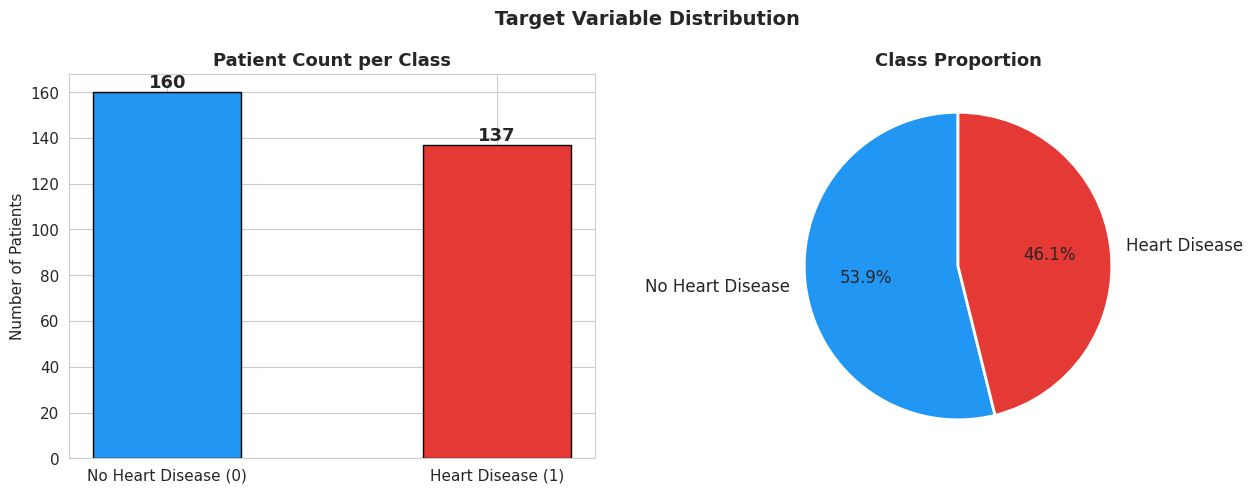


 BASELINE accuracy (always predict majority class) = 53.9%
   Our Decision Tree MUST beat 53.9% to prove learning is useful!


In [ ]:
#  2.3  Class Distribution
#  Are there equal numbers of patients with and without heart disease?
#  If very imbalanced (e.g., 95% No Disease), a dumb model
#  that ALWAYS says 'No Disease' would get 95% accuracy!
#  That's the BASELINE from lecture — we must beat it.

counts = df['target'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
clr = ['#2196F3', '#E53935']
axes[0].bar(['No Heart Disease (0)', 'Heart Disease (1)'],
             counts.values, color=clr, edgecolor='black', width=0.45)
axes[0].set_title('Patient Count per Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=13, fontweight='bold')

# Pie chart
axes[1].pie(counts.values,
             labels=['No Heart Disease', 'Heart Disease'],
             colors=clr, autopct='%1.1f%%', startangle=90,
             textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle(' Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

baseline = counts[counts.idxmax()] / len(df) * 100
print(f"\n BASELINE accuracy (always predict majority class) = {baseline:.1f}%")
print(f"   Our Decision Tree MUST beat {baseline:.1f}% to prove learning is useful!")

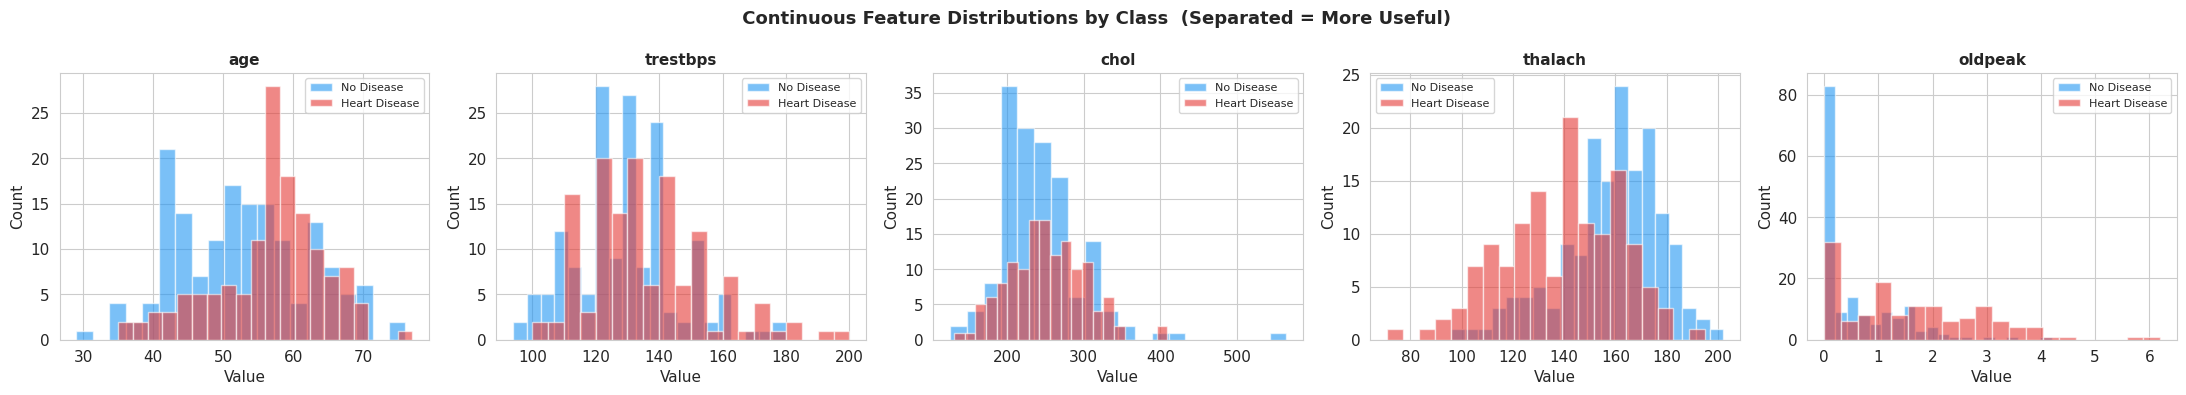

 Key observation:
   • 'thalach' (max heart rate): Heart disease patients have LOWER max heart rate
   • 'oldpeak' (ST depression) : Heart disease patients have HIGHER values
   → These two features will likely have high Information Gain (Step 5)!


In [ ]:
#  2.4  Feature Distributions by Class
#  For each feature, we draw overlapping histograms:
#     Blue  = No Heart Disease patients
#     Red   = Heart Disease patients
#  If the two distributions OVERLAP a lot → feature is weak (hard to separate)
#  If they are SEPARATED clearly → feature is POWERFUL for classification

continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, feat in enumerate(continuous_features):
    for outcome, color, label in [(0, '#2196F3', 'No Disease'), (1, '#E53935', 'Heart Disease')]:
        axes[i].hist(df[df['target'] == outcome][feat],
                     bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle(' Continuous Feature Distributions by Class  (Separated = More Useful)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Key observation:")
print("   • 'thalach' (max heart rate): Heart disease patients have LOWER max heart rate")
print("   • 'oldpeak' (ST depression) : Heart disease patients have HIGHER values")
print("   → These two features will likely have high Information Gain (Step 5)!")

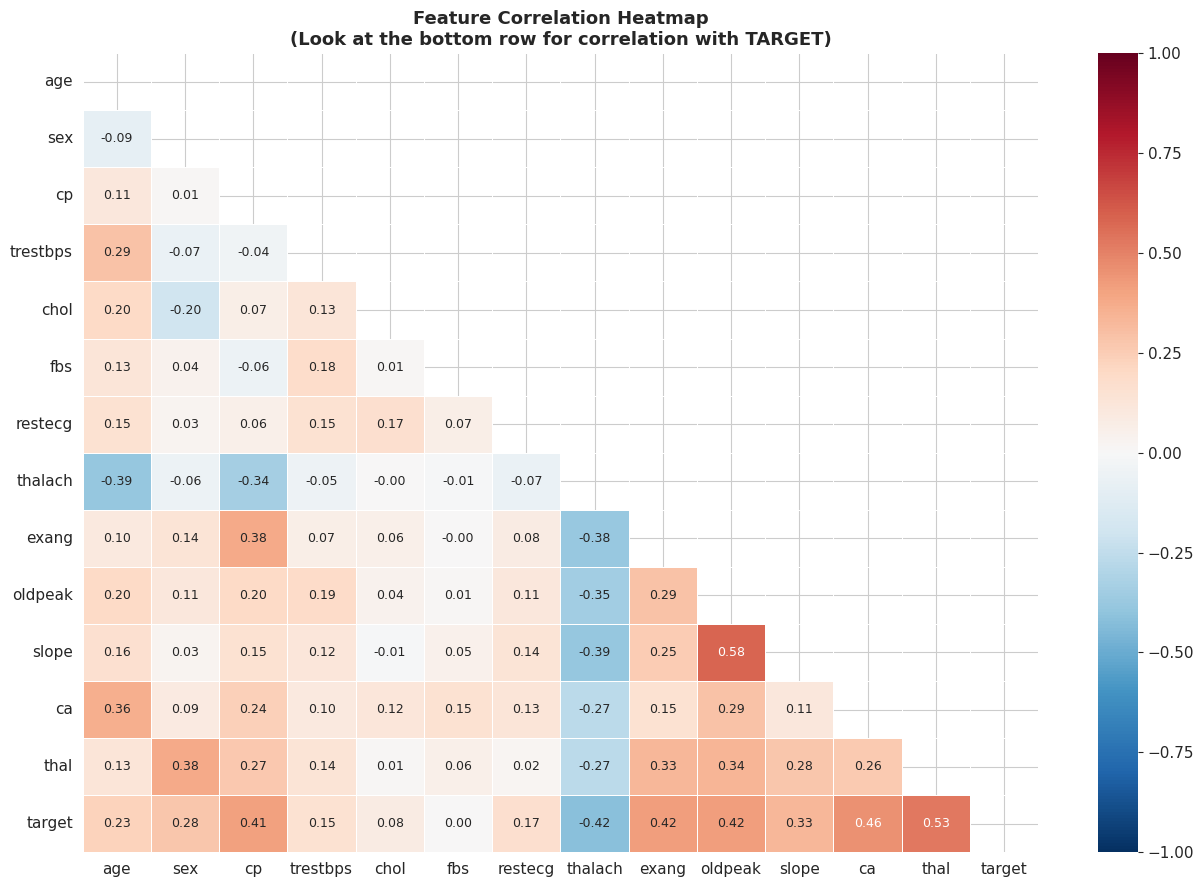


 Features most correlated with Heart Disease (target):
   thal        :                                0.530
   ca          :                                0.460
   exang       :                                0.420
   thalach     :                                0.420
   oldpeak     :                                0.420
   cp          :                                0.410
   slope       :                                0.330
   sex         :                                0.280
   age         :                                0.230
   restecg     :                                0.170
   trestbps    :                                0.150
   chol        :                                0.080
   fbs         :                                0.000


In [ ]:
#  2.5  Correlation Heatmap
#  Shows how strongly two features move together.
#  Value close to +1 → both increase together
#  Value close to -1 → one increases as other decreases
#  Value close to  0 → no relationship
#
#  We also look at correlation with TARGET — this tells us
#  which features are most related to the disease.
plt.figure(figsize=(13, 9))
corr_matrix = df.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Only show lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap\n(Look at the bottom row for correlation with TARGET)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlated features with target
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print("\n Features most correlated with Heart Disease (target):")
for feat, val in target_corr.items():
    bar = ' ' * int(val * 30)
    print(f"   {feat:<12}: {bar:<30} {val:.3f}")

---
##  STEP 3 — Feature Selection

**What are we doing here?**
Not all 13 features are equally useful for predicting heart disease. Using too many useless features can actually **hurt** model accuracy (they add noise). Feature selection means **choosing only the most relevant features**.

This is the same concept from the lecture: in the loan dataset, `Own_House` was a much better splitting attribute than `Age` because it reduced impurity more.

We will rank features using **3 different methods**, then combine their rankings to pick the best ones:
1. **Correlation** — linear relationship with target
2. **Mutual Information** — directly measures Information Gain (from lecture formula!)
3. **Tree-based importance** — let a quick tree tell us what it found useful

In [ ]:
#  Separate features (X) from class label (y)
#  X = the 13 input columns  (what we know about the patient)
#  y = the target column     (what we want to predict)
X = df.drop('target', axis=1)
y = df['target']

print(f"X — Feature matrix : {X.shape[0]} patients × {X.shape[1]} features")
print(f"y — Class labels   : {y.shape[0]} labels  | Classes: {sorted(y.unique())}")
print(f"\nAll features: {list(X.columns)}")

X — Feature matrix : 297 patients × 13 features
y — Class labels   : 297 labels  | Classes: [np.int64(0), np.int64(1)]

All features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


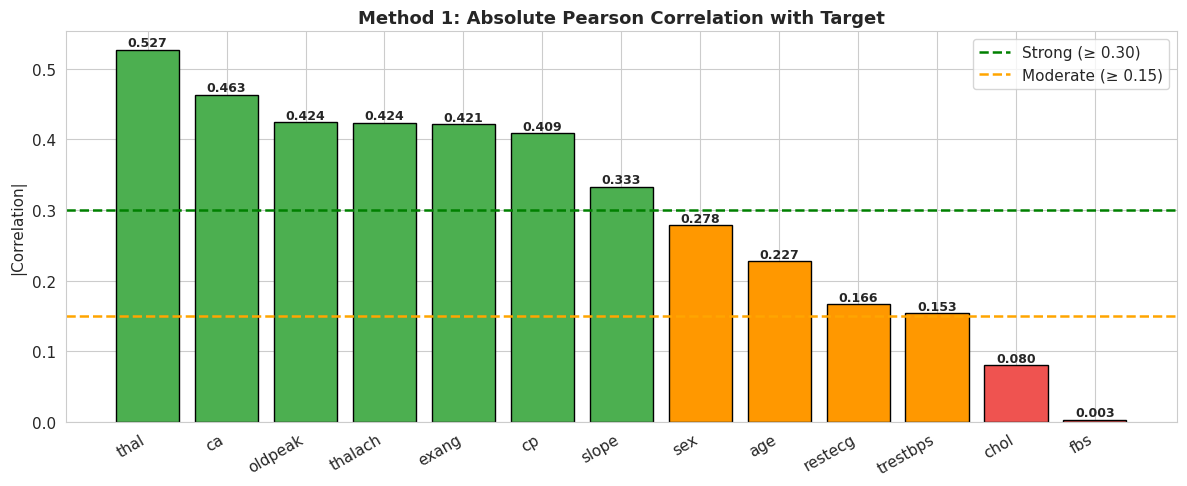

In [ ]:
#  METHOD 1 — Pearson Correlation with Target
#  Simple but effective: features that strongly co-vary with the
#  class label are likely useful for classification.
#  We take the ABSOLUTE value because both + and - correlations matter.

corr_scores = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#4CAF50' if v >= 0.3 else '#FF9800' if v >= 0.15 else '#EF5350'
              for v in corr_scores.values]
bars = ax.bar(corr_scores.index, corr_scores.values, color=bar_colors, edgecolor='black')
ax.axhline(0.30, color='green',  linestyle='--', lw=1.8, label='Strong (≥ 0.30)')
ax.axhline(0.15, color='orange', linestyle='--', lw=1.8, label='Moderate (≥ 0.15)')
ax.set_title('Method 1: Absolute Pearson Correlation with Target', fontsize=13, fontweight='bold')
ax.set_ylabel('|Correlation|')
ax.legend()
ax.set_xticklabels(corr_scores.index, rotation=30, ha='right')
for bar, val in zip(bars, corr_scores.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

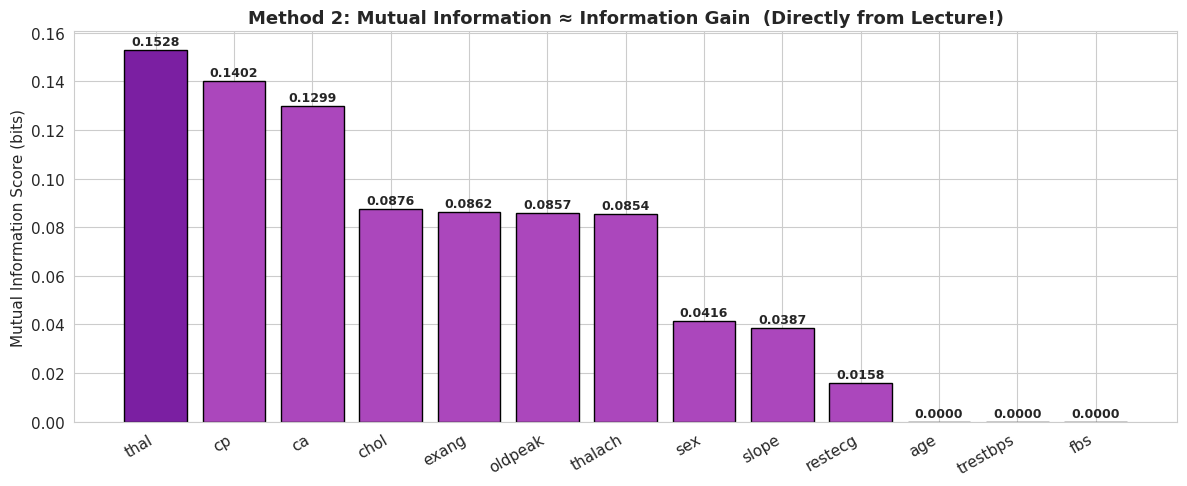


The feature with highest Mutual Information = thal
   → This will be chosen as the ROOT of the decision tree (Step 7)!


In [ ]:

#  METHOD 2 — Mutual Information (Information Gain)
#  This is DIRECTLY from our lecture!
#  Mutual Information measures how much knowing a feature REDUCES
#  our uncertainty about the class label.
#  Higher score = more useful feature = good candidate for tree root!

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors2 = ['#7B1FA2' if v >= 0.15 else '#AB47BC' for v in mi_series.values]
bars2 = ax.bar(mi_series.index, mi_series.values, color=bar_colors2, edgecolor='black')
ax.set_title('Method 2: Mutual Information ≈ Information Gain  (Directly from Lecture!)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mutual Information Score (bits)')
ax.set_xticklabels(mi_series.index, rotation=30, ha='right')
for bar, val in zip(bars2, mi_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nThe feature with highest Mutual Information = {mi_series.idxmax()}")
print(f"   → This will be chosen as the ROOT of the decision tree (Step 7)!")

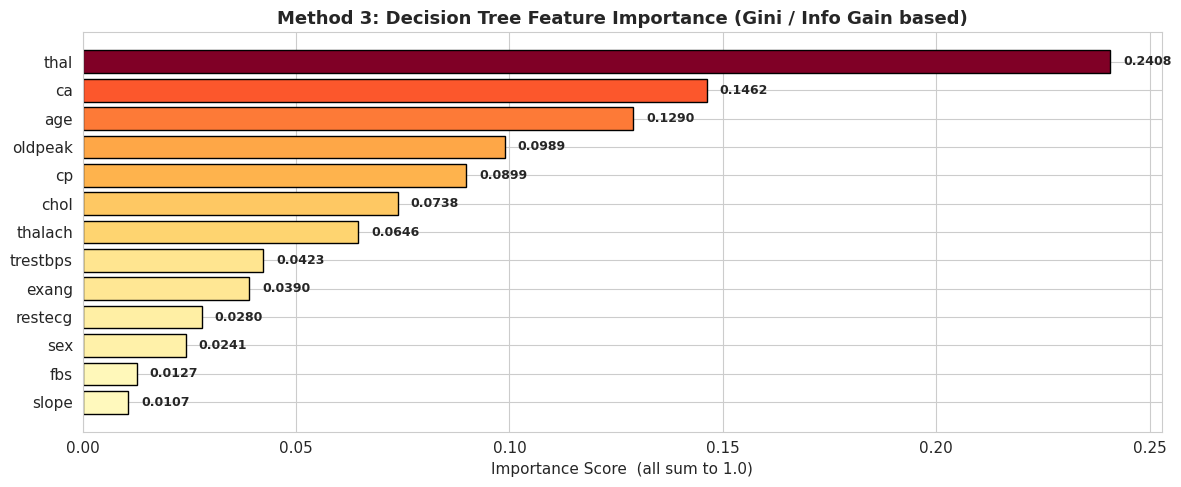

In [ ]:
#  METHOD 3 — Decision Tree Feature Importance
#  Train a quick, shallow tree and ask: which features did it
#  actually use for splitting? Features used more = more important.
#  Internally, this also uses Information Gain (entropy criterion).

quick_tree = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
quick_tree.fit(X, y)
importance_series = pd.Series(quick_tree.feature_importances_,
                               index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
palette = plt.cm.YlOrRd(importance_series.values / importance_series.max())
ax.barh(importance_series.index[::-1], importance_series.values[::-1],
        color=palette[::-1], edgecolor='black')
ax.set_title('Method 3: Decision Tree Feature Importance (Gini / Info Gain based)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score  (all sum to 1.0)')
for i, (feat, val) in enumerate(zip(importance_series.index[::-1], importance_series.values[::-1])):
    ax.text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#  COMBINE all 3 rankings into one summary table
#  We average the rank positions across all 3 methods.
#  Lower average rank = feature is consistently important.
#  We then pick the TOP 7 features to use for our model.
summary = pd.DataFrame({
    'Correlation Rank'    : corr_scores.rank(ascending=False).astype(int),
    'Mutual Info Rank'    : mi_series.rank(ascending=False).astype(int),
    'Tree Importance Rank': importance_series.rank(ascending=False).astype(int),
})
summary['Avg Rank'] = summary.mean(axis=1).round(2)
summary = summary.sort_values('Avg Rank')

print("=" * 70)
print(" FEATURE SELECTION SUMMARY  |  Lower Avg Rank = Better Feature")
print("=" * 70)
print(summary.to_string())

# Select top 7 features
top_features = summary.head(7).index.tolist()
print(f"\n TOP 7 Selected Features: {top_features}")
print("   These will be used to build and train our Decision Tree in the next steps.")

 FEATURE SELECTION SUMMARY  |  Lower Avg Rank = Better Feature
          Correlation Rank  Mutual Info Rank  Tree Importance Rank  Avg Rank
thal                     1                 1                     1      1.00
ca                       2                 3                     2      2.33
oldpeak                  3                 6                     4      4.33
cp                       6                 2                     5      4.33
thalach                  4                 7                     7      6.00
exang                    5                 5                     9      6.33
chol                    12                 4                     6      7.33
age                      9                12                     3      8.00
sex                      8                 8                    11      9.00
slope                    7                 9                    13      9.67
restecg                 10                10                    10     10.00
trestbps     

---
##  STEP 4 — Feature Extraction with PCA

**What are we doing here?**
Feature *selection* picks existing features. Feature *extraction* creates **brand new features** by combining the originals. The most common technique is **PCA (Principal Component Analysis)**.

PCA compresses 13 features into fewer **components** that still capture most of the information. We use 2 components here purely to **visualize** the data in 2D  to see if heart disease patients and healthy patients are naturally separable.

> **Note:** Decision Trees work best with original features (they are interpretable). PCA is more useful with algorithms like SVM or Neural Networks. But understanding PCA is essential in AI/ML.

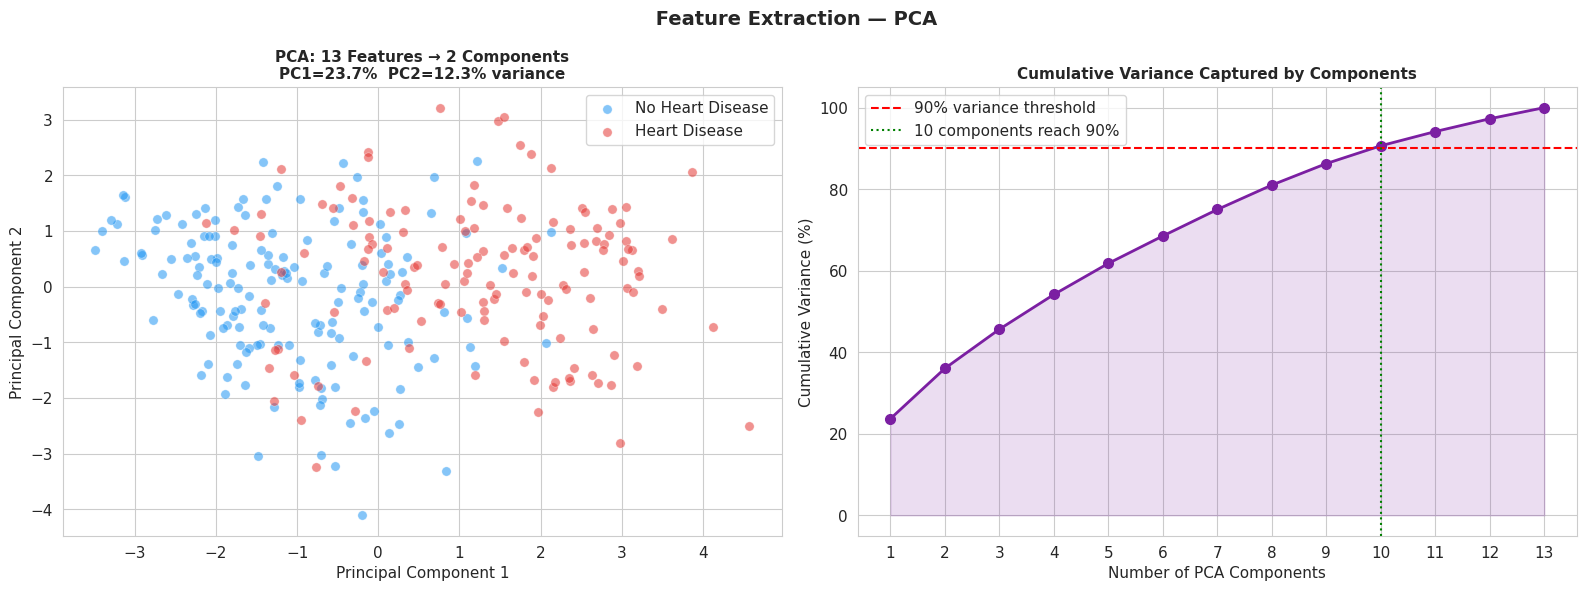


 Only 10 components (out of 13) are needed to capture 90% of all information.
   The 2D scatter shows partial class separation — our tree will do better
   because it can split along multiple axes, not just 2.


In [ ]:
#  Before PCA we must STANDARDIZE features
#  (make all features have mean=0, std=1)
#  Because 'chol' ranges 126–564 while 'fbs' is just 0 or 1.
#  Without scaling, chol would dominate PCA unfairly.

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

# Reduce to 2 dimensions for visualization
pca_2d    = PCA(n_components=2, random_state=42)
X_pca_2d  = pca_2d.fit_transform(X_scaled)

# Compute full PCA to see how many components capture 90% variance
pca_full  = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar    = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: 2D scatter of patients in PCA space ---
for cls, color, label in [(0, '#2196F3', 'No Heart Disease'), (1, '#E53935', 'Heart Disease')]:
    mask = (y == cls)
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=label, alpha=0.55, s=45,
                    edgecolors='white', linewidth=0.4)
axes[0].set_title(f'PCA: 13 Features → 2 Components\n'
                  f'PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%  '
                  f'PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}% variance',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend()

# --- Right: Cumulative variance vs number of components ---
comps = range(1, len(cumvar) + 1)
axes[1].plot(comps, cumvar, 'o-', color='#7B1FA2', linewidth=2, markersize=7)
axes[1].fill_between(comps, cumvar, alpha=0.15, color='#7B1FA2')
axes[1].axhline(90, color='red', linestyle='--', lw=1.5, label='90% variance threshold')
n_for_90 = np.argmax(cumvar >= 90) + 1
axes[1].axvline(n_for_90, color='green', linestyle=':', lw=1.5,
                label=f'{n_for_90} components reach 90%')
axes[1].set_title('Cumulative Variance Captured by Components', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xticks(list(comps))
axes[1].legend()

plt.suptitle(' Feature Extraction — PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Only {n_for_90} components (out of 13) are needed to capture 90% of all information.")
print(f"   The 2D scatter shows partial class separation — our tree will do better")
print(f"   because it can split along multiple axes, not just 2.")

---
##  STEP 5 — Entropy & Information Gain (Manual Calculation)

**What are we doing here?**
This is the **heart of the lecture!** The Decision Tree algorithm picks which feature to split on using **Information Gain**. Here we manually calculate it ourselves so you can see exactly how it works:

$$\text{entropy}(D) = -\sum_{j=1}^{|C|} \Pr(c_j) \log_2 \Pr(c_j)$$

$$\text{gain}(D, A_i) = \text{entropy}(D) - \text{entropy}_{A_i}(D)$$

The feature with the **highest Information Gain** is chosen as the root of the tree. This is the same process C4.5 (the famous decision tree algorithm) follows.

In [ ]:
#  ENTROPY FUNCTION
#  Given a list of class labels, compute how 'disordered' they are.
#  entropy = 0   → all same class (perfectly pure, ideal leaf)
#  entropy = 1   → 50-50 split (maximum uncertainty)

def compute_entropy(labels):
    """Compute entropy of a set of class labels."""
    if len(labels) == 0:
        return 0.0
    _, counts      = np.unique(labels, return_counts=True)
    probabilities  = counts / len(labels)
    # -Σ p * log2(p)   — ignore p=0 because 0*log(0) is defined as 0
    return -np.sum([p * np.log2(p) for p in probabilities if p > 0])


#  INFORMATION GAIN FUNCTION
#  1) Compute entropy of full dataset  (parent entropy)
#  2) Bin continuous feature into categories
#  3) Compute weighted entropy after split
#  4) Gain = parent entropy - weighted child entropy

def compute_info_gain(dataframe, feature, target='target', bins=4):
    """Compute Information Gain of splitting on a feature."""
    parent_entropy = compute_entropy(dataframe[target])
    total          = len(dataframe)

    # Bin the feature (handles both continuous and discrete)
    tmp = dataframe[[feature, target]].copy()
    tmp['bin'] = pd.cut(tmp[feature], bins=bins, labels=False, duplicates='drop')

    weighted_child_entropy = 0.0
    for bin_val in tmp['bin'].dropna().unique():
        subset  = tmp[tmp['bin'] == bin_val][target]
        weight  = len(subset) / total          # |Dj| / |D|  from lecture formula
        weighted_child_entropy += weight * compute_entropy(subset)

    gain = parent_entropy - weighted_child_entropy
    return parent_entropy, weighted_child_entropy, gain



#  STEP 5a — Compute overall dataset entropy
p1 = y.mean()          # Pr(Heart Disease = 1)
p0 = 1 - p1            # Pr(No Heart Disease = 0)
D_entropy = compute_entropy(y)

print("=" * 65)
print(" STEP 5 — ENTROPY & INFORMATION GAIN (Manual Calculation)")
print("=" * 65)
print(f"\n Dataset D has {len(y)} patients:")
print(f"   Heart Disease (1)    : {(y==1).sum()} patients  →  Pr(1) = {p1:.4f}")
print(f"   No Heart Disease (0) : {(y==0).sum()} patients  →  Pr(0) = {p0:.4f}")
print(f"\n  entropy(D) = -[{p1:.3f}×log₂({p1:.3f})] - [{p0:.3f}×log₂({p0:.3f})]")
print(f"             = {D_entropy:.4f} bits")
print(f"\n   (For perfect 50-50 split entropy = 1.0 — maximum uncertainty)")
print(f"   (For all same class  entropy = 0.0 — perfectly pure)")

 STEP 5 — ENTROPY & INFORMATION GAIN (Manual Calculation)

 Dataset D has 297 patients:
   Heart Disease (1)    : 137 patients  →  Pr(1) = 0.4613
   No Heart Disease (0) : 160 patients  →  Pr(0) = 0.5387

  entropy(D) = -[0.461×log₂(0.461)] - [0.539×log₂(0.539)]
             = 0.9957 bits

   (For perfect 50-50 split entropy = 1.0 — maximum uncertainty)
   (For all same class  entropy = 0.0 — perfectly pure)


In [ ]:
#  STEP 5b — Compute Information Gain for every feature
#  This is what the Decision Tree algorithm does at EACH node
#  to decide which attribute to split on!

gains_dict = {}
print(f"\n{'Feature':<13} {'Parent H(D)':>12} {'After Split':>12} {'Info GAIN':>11} {'Best?':>8}")
print("─" * 62)

for feat in X.columns:
    pe, we, gain = compute_info_gain(df, feat)
    gains_dict[feat] = gain

best_feature = max(gains_dict, key=gains_dict.get)

for feat, gain in sorted(gains_dict.items(), key=lambda x: -x[1]):
    pe, we, _ = compute_info_gain(df, feat)
    marker = '  ROOT NODE' if feat == best_feature else ''
    print(f"{feat:<13} {pe:>12.4f} {we:>12.4f} {gain:>11.4f}  {marker}")

print(f"\n Feature with highest Information Gain = '{best_feature}'")
print(f"   → This becomes the ROOT NODE of the Decision Tree!")


Feature        Parent H(D)  After Split   Info GAIN    Best?
──────────────────────────────────────────────────────────────
thal                0.9957       0.7854      0.2102    ROOT NODE
cp                  0.9957       0.7985      0.1972  
ca                  0.9957       0.8110      0.1846  
exang               0.9957       0.8634      0.1323  
thalach             0.9957       0.8634      0.1323  
oldpeak             0.9957       0.8854      0.1103  
slope               0.9957       0.8869      0.1088  
age                 0.9957       0.9346      0.0610  
sex                 0.9957       0.9378      0.0579  
restecg             0.9957       0.9722      0.0235  
trestbps            0.9957       0.9796      0.0160  
chol                0.9957       0.9836      0.0121  
fbs                 0.9957       0.9957      0.0000  

 Feature with highest Information Gain = 'thal'
   → This becomes the ROOT NODE of the Decision Tree!


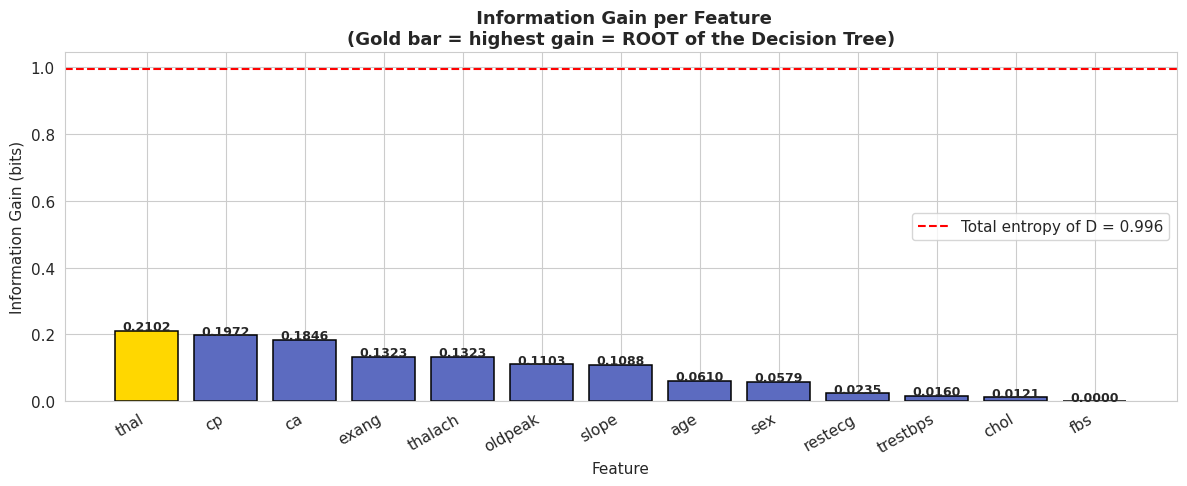

In [ ]:

#  Visualize Information Gain for all features
sorted_gains = dict(sorted(gains_dict.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12, 5))
bar_cols = ['#FFD700' if k == best_feature else '#5C6BC0' for k in sorted_gains]
bars = plt.bar(sorted_gains.keys(), sorted_gains.values(),
               color=bar_cols, edgecolor='black', linewidth=1.1)
plt.axhline(D_entropy, color='red', linestyle='--', lw=1.5,
            label=f'Total entropy of D = {D_entropy:.3f}')
plt.title(' Information Gain per Feature\n'
          '(Gold bar = highest gain = ROOT of the Decision Tree)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Information Gain (bits)')
plt.legend()
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, sorted_gains.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  STEP 6 — Splitting Data into Training and Testing Sets

**What are we doing here?**
From the lecture: the supervised learning process has **two steps — Training and Testing**.

We cannot use the same data for both training and testing — that would be like giving students the exam answers before the exam! The model would just memorize the data without actually *learning*.

We split our dataset:
- **70% → Training set** — the model learns from this
- **30% → Testing set** — we use this to measure real-world accuracy

We also use `stratify=y` to ensure both sets have the same class balance.

In [ ]:
#  Use only the top-selected features (from Step 3)
#  This removes the noisy/irrelevant features we identified earlier
X_selected = df[top_features]

# Split: 70% train, 30% test
# stratify=y  → preserve class ratio in both sets
# random_state=42 → reproducible split every run
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size   = 0.30,
    random_state= 42,
    stratify    = y
)

print("=" * 58)
print(" TRAIN / TEST SPLIT  (Lecture Step 1 → Step 2)")
print("=" * 58)
print(f"  Total patients  : {len(df)}")
print(f"  Training set    : {len(X_train)} patients  ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Testing set     : {len(X_test)}  patients  ({len(X_test)/len(df)*100:.0f}%)")
print(f"\n  Training class  : No Disease={( y_train==0).sum()}  |  Disease={(y_train==1).sum()}")
print(f"  Testing  class  : No Disease={(y_test==0).sum()}   |  Disease={(y_test==1).sum()}")
print(f"\n  Features used   : {top_features}")

baseline_acc = (y_test == y_test.mode()[0]).mean() * 100
print(f"\n  Baseline accuracy (no model, always predict majority): {baseline_acc:.1f}%")

 TRAIN / TEST SPLIT  (Lecture Step 1 → Step 2)
  Total patients  : 297
  Training set    : 207 patients  (70%)
  Testing set     : 90  patients  (30%)

  Training class  : No Disease=112  |  Disease=95
  Testing  class  : No Disease=48   |  Disease=42

  Features used   : ['thal', 'ca', 'oldpeak', 'cp', 'thalach', 'exang', 'chol']

  Baseline accuracy (no model, always predict majority): 53.3%


---
##  STEP 7 — Building the Full (Unpruned) Decision Tree

**What are we doing here?**
Now we actually build the Decision Tree classifier! We use `criterion='entropy'` so the tree uses **Information Gain** (the formula we calculated in Step 5) at every node to decide the best split.

A **full tree** has no depth limit — it keeps splitting until every leaf node contains only one class (entropy = 0). While this gives 100% accuracy on training data, it tends to **overfit** — it memorizes the training data rather than learning generalizable patterns.

We will then compare this with the pruned tree in Step 8.

In [ ]:
#  Train the FULL (unpruned) Decision Tree
#  criterion='entropy' → uses Information Gain from lecture
#  max_depth=None      → no limit, tree grows until all leaves are pure

dt_full = DecisionTreeClassifier(
    criterion   = 'entropy',   # Information Gain (lecture formula)
    max_depth   = None,        # No pruning — full tree
    random_state= 42
)

# ── STEP 1 from lecture: TRAINING ──
dt_full.fit(X_train, y_train)

# ── STEP 2 from lecture: TESTING ──
y_pred_full      = dt_full.predict(X_test)
acc_train_full   = accuracy_score(y_train, dt_full.predict(X_train)) * 100
acc_test_full    = accuracy_score(y_test,  y_pred_full)              * 100
overfit_gap      = acc_train_full - acc_test_full

print("=" * 58)
print(" FULL (UNPRUNED) DECISION TREE — Results")
print("=" * 58)
print(f"  Tree depth         : {dt_full.get_depth()}")
print(f"  Number of leaves   : {dt_full.get_n_leaves()}")
print(f"  Training accuracy  : {acc_train_full:.2f}%")
print(f"  Testing  accuracy  : {acc_test_full:.2f}%")
print(f"  Overfitting gap    : {overfit_gap:.2f}%  (train − test)")
if overfit_gap > 8:
    print(f"\n   OVERFITTING DETECTED!")
    print(f"     The tree memorized training data but struggles on new patients.")
    print(f"     Solution → PRUNING (Step 8) will fix this.")

 FULL (UNPRUNED) DECISION TREE — Results
  Tree depth         : 12
  Number of leaves   : 47
  Training accuracy  : 100.00%
  Testing  accuracy  : 71.11%
  Overfitting gap    : 28.89%  (train − test)

   OVERFITTING DETECTED!
     The tree memorized training data but struggles on new patients.
     Solution → PRUNING (Step 8) will fix this.


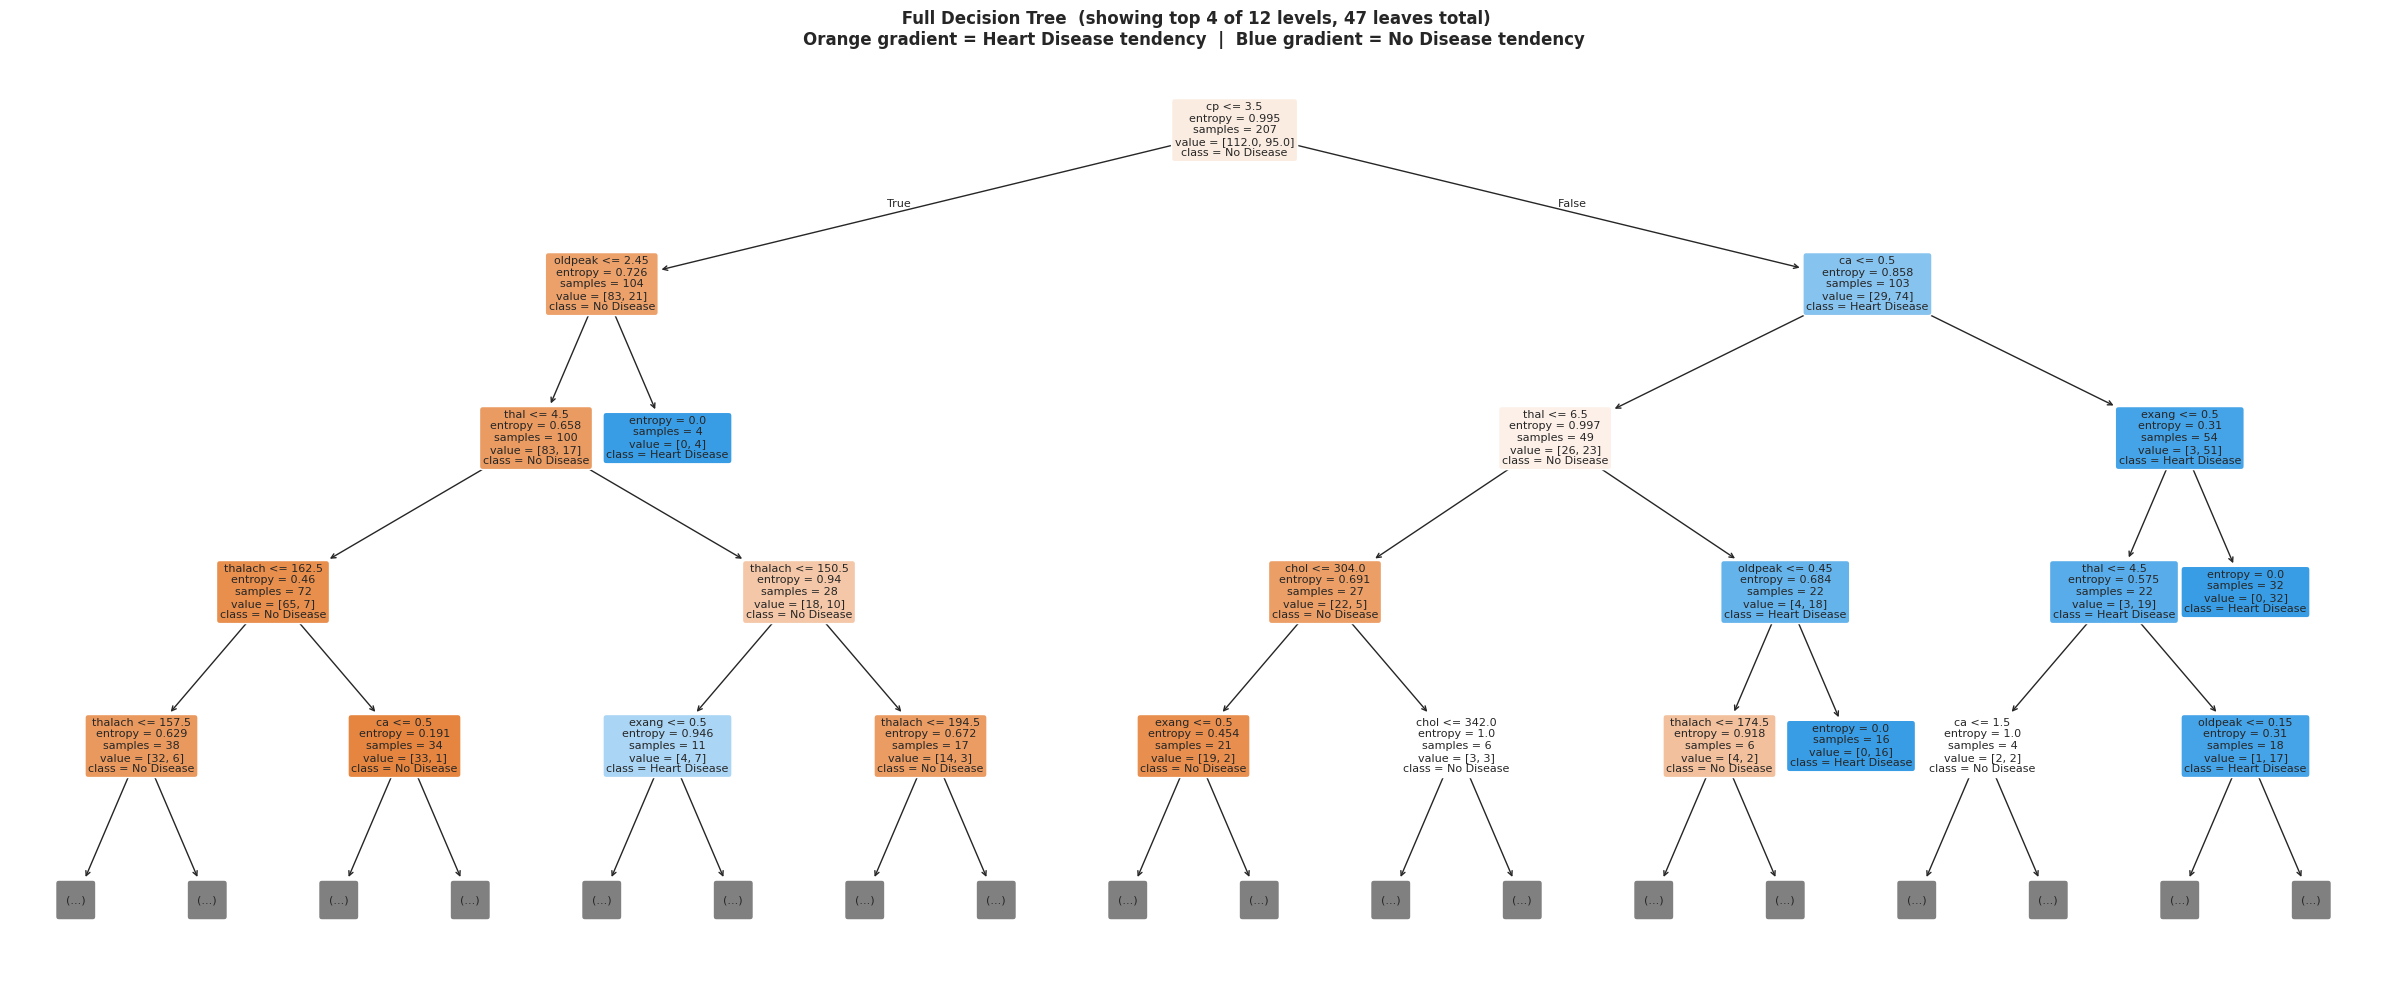

Each node box contains:
   feature ≤ value  → the split condition
   entropy          → impurity of this node (0=pure, 1=max uncertainty)
   samples          → how many training patients reach this node
   value = [a, b]   → [count class 0, count class 1]
   class            → majority class label at this node


In [ ]:

#  Visualize the full tree (only first 4 levels shown)
#  The full tree is too large to display entirely, so we zoom in
#  on the top 4 levels which contain the most important splits.

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_full,
    max_depth      = 4,
    feature_names  = top_features,
    class_names    = ['No Disease', 'Heart Disease'],
    filled         = True,
    rounded        = True,
    fontsize       = 8,
    ax             = ax
)
ax.set_title(
    f' Full Decision Tree  (showing top 4 of {dt_full.get_depth()} levels, '
    f'{dt_full.get_n_leaves()} leaves total)\n'
    f'Orange gradient = Heart Disease tendency  |  Blue gradient = No Disease tendency',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("Each node box contains:")
print("   feature ≤ value  → the split condition")
print("   entropy          → impurity of this node (0=pure, 1=max uncertainty)")
print("   samples          → how many training patients reach this node")
print("   value = [a, b]   → [count class 0, count class 1]")
print("   class            → majority class label at this node")

---
##  STEP 8  Pruning the Decision Tree

**What are we doing here?**
Pruning means **cutting back** the decision tree to prevent overfitting. A full tree is like a student who memorized the textbook word-for-word but can't apply the concepts to a new problem.

We control tree size using `max_depth`. We will:
1. Train trees with depth 1, 2, 3, … 15
2. Record both training accuracy and testing accuracy
3. Plot them — the gap between curves shows how much the model is overfitting
4. Find the **sweet spot** where test accuracy is highest
5. Build the final pruned tree at that optimal depth

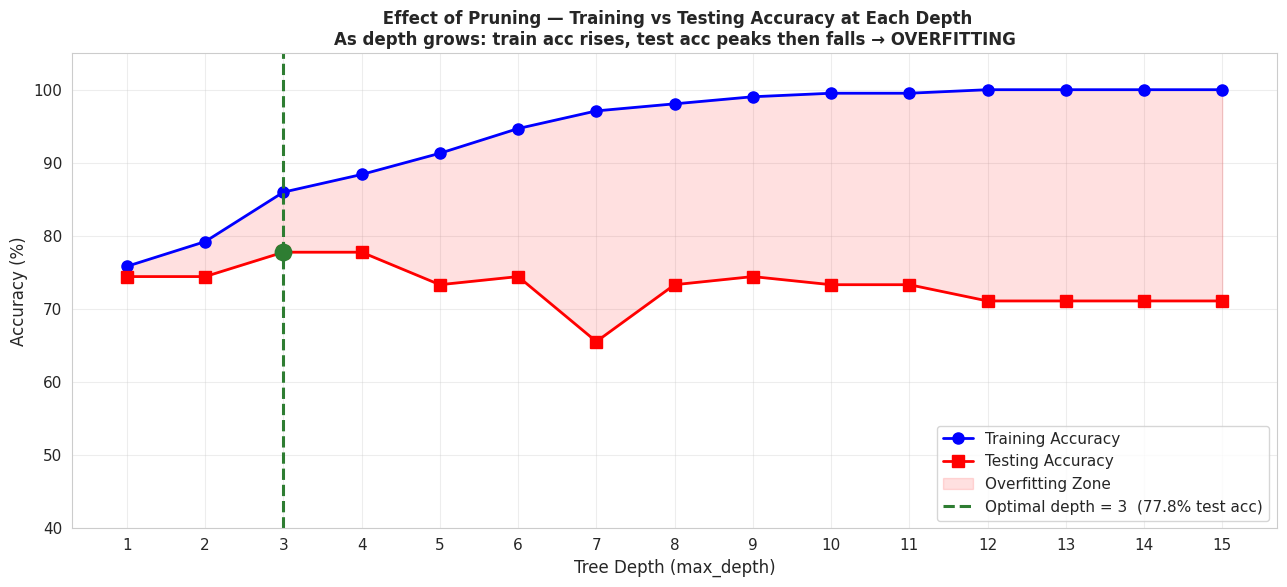


 Optimal max_depth = 3
   Testing accuracy at this depth = 77.78%
   (Full tree depth=12 gave only 71.11% on test — overfitting!)


In [ ]:

#  Train trees at every depth from 1 to 15 and record accuracy
#  This sweep helps us find the optimal pruning depth

depths      = list(range(1, 16))
train_accs  = []
test_accs   = []

for d in depths:
    tree = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)) * 100)
    test_accs.append( accuracy_score(y_test,  tree.predict(X_test))  * 100)

best_depth    = depths[np.argmax(test_accs)]
best_test_acc = max(test_accs)

# ── Plot the depth vs accuracy curve ──
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(depths, train_accs, 'b-o', lw=2, ms=8, label='Training Accuracy')
ax.plot(depths, test_accs,  'r-s', lw=2, ms=8, label='Testing Accuracy')
ax.fill_between(depths, train_accs, test_accs,
                alpha=0.12, color='red', label='Overfitting Zone')
ax.axvline(best_depth, color='#2E7D32', lw=2.2, linestyle='--',
           label=f'Optimal depth = {best_depth}  ({best_test_acc:.1f}% test acc)')
ax.scatter([best_depth], [best_test_acc], color='#2E7D32', s=140, zorder=5)
ax.set_xlabel('Tree Depth (max_depth)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(' Effect of Pruning — Training vs Testing Accuracy at Each Depth\n'
             'As depth grows: train acc rises, test acc peaks then falls → OVERFITTING',
             fontsize=12, fontweight='bold')
ax.set_xticks(depths)
ax.legend(fontsize=11)
ax.set_ylim(40, 105)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print(f"\n Optimal max_depth = {best_depth}")
print(f"   Testing accuracy at this depth = {best_test_acc:.2f}%")
print(f"   (Full tree depth={dt_full.get_depth()} gave only {acc_test_full:.2f}% on test — overfitting!)")

In [ ]:

#  Build the FINAL PRUNED Decision Tree at the optimal depth
#  Additional pruning parameters:
#  min_samples_split → a node needs at least N samples to split further
#  min_samples_leaf  → every leaf must contain at least N samples
#  These prevent the tree from learning from statistical noise.

dt_pruned = DecisionTreeClassifier(
    criterion        = 'entropy',   # Information Gain
    max_depth        = best_depth,  # Optimal depth from sweep above
    min_samples_split= 8,           # Need ≥ 8 samples to split
    min_samples_leaf = 4,           # Leaves must have ≥ 4 samples
    random_state     = 42
)
dt_pruned.fit(X_train, y_train)
y_pred_pruned     = dt_pruned.predict(X_test)
acc_train_pruned  = accuracy_score(y_train, dt_pruned.predict(X_train)) * 100
acc_test_pruned   = accuracy_score(y_test,  y_pred_pruned)              * 100

print("=" * 58)
print(f"  PRUNED DECISION TREE — Results  (max_depth={best_depth})")
print("=" * 58)
print(f"  Tree depth         : {dt_pruned.get_depth()}")
print(f"  Number of leaves   : {dt_pruned.get_n_leaves()}")
print(f"  Training accuracy  : {acc_train_pruned:.2f}%")
print(f"  Testing  accuracy  : {acc_test_pruned:.2f}%")
print(f"  Overfitting gap    : {(acc_train_pruned-acc_test_pruned):.2f}%  (much smaller now!)")

  PRUNED DECISION TREE — Results  (max_depth=3)
  Tree depth         : 3
  Number of leaves   : 7
  Training accuracy  : 85.99%
  Testing  accuracy  : 77.78%
  Overfitting gap    : 8.21%  (much smaller now!)


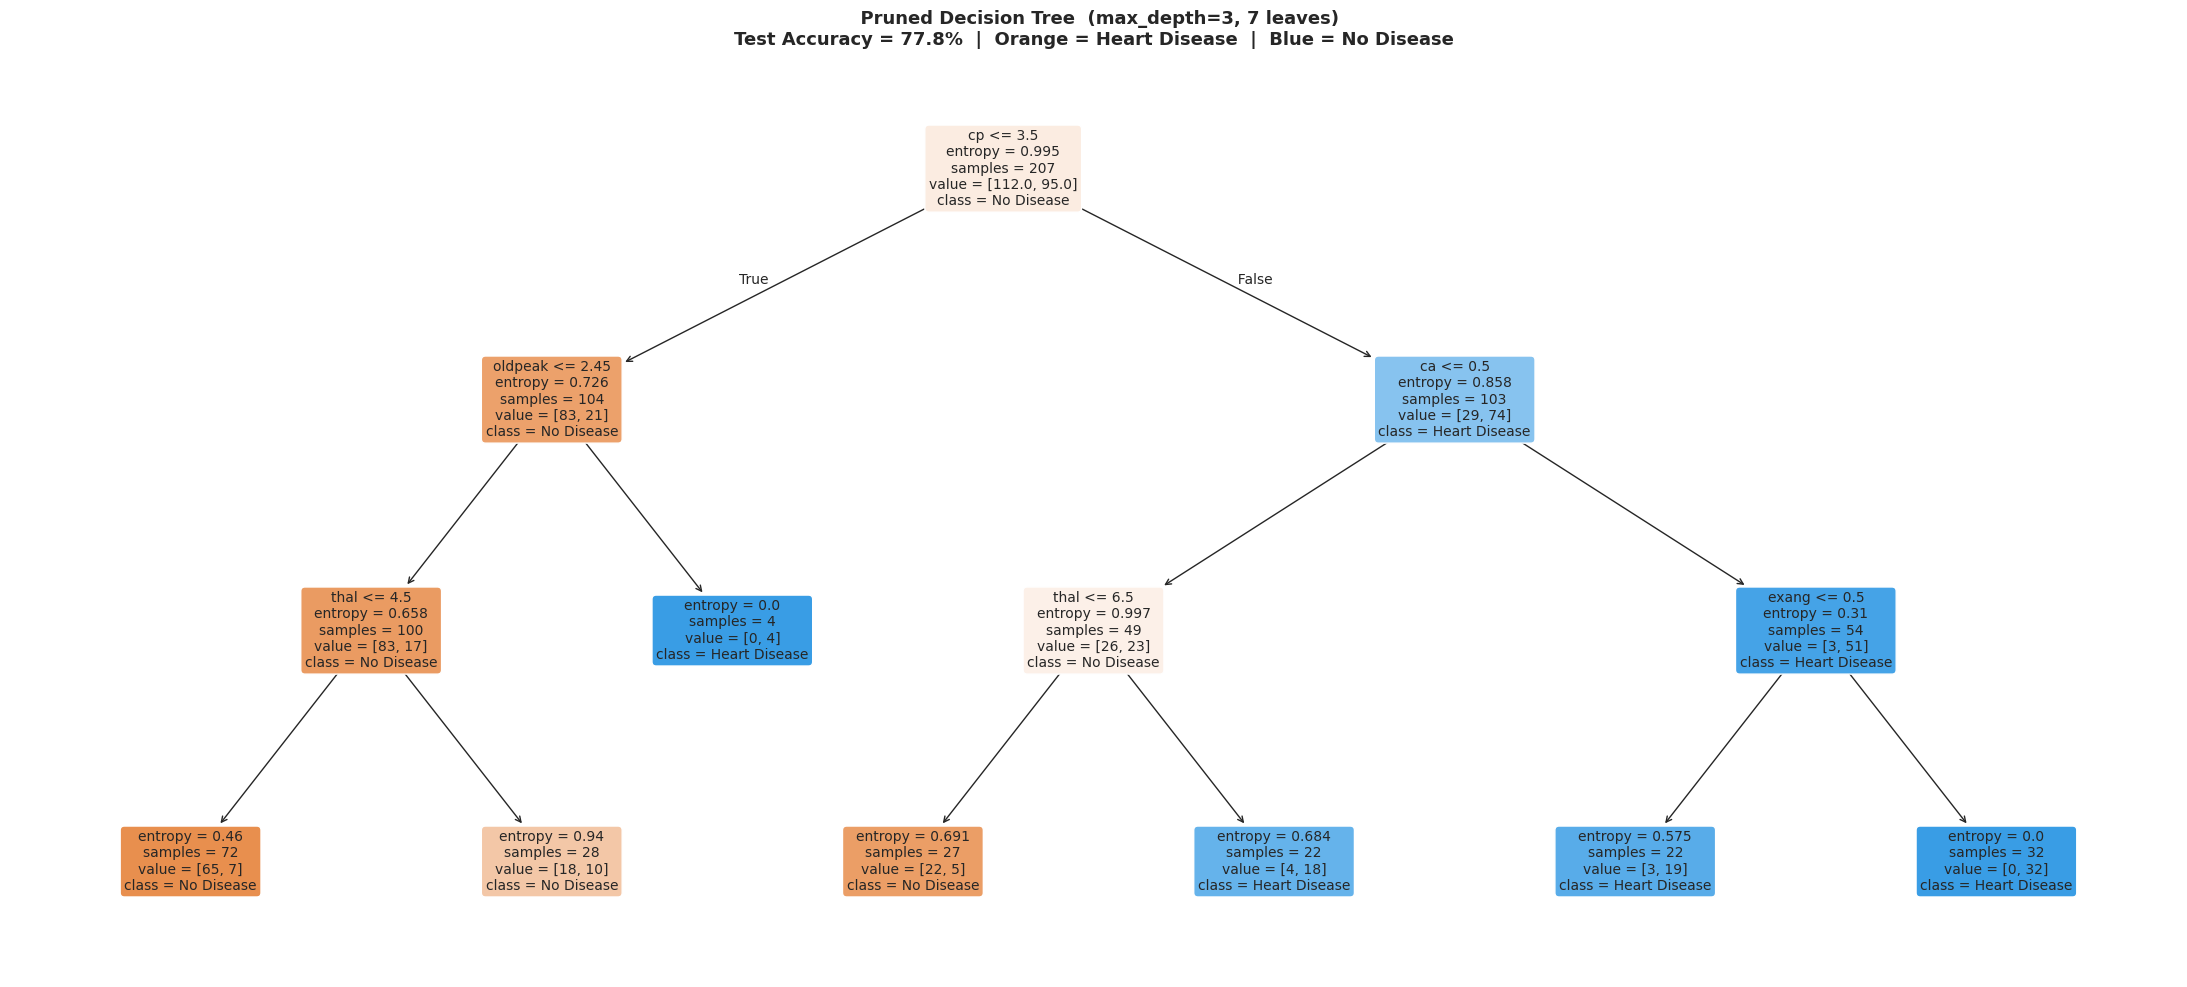

 PRUNED TREE AS IF-THEN RULES  (path from root → each leaf)
|--- cp <= 3.50
|   |--- oldpeak <= 2.45
|   |   |--- thal <= 4.50
|   |   |   |--- class: 0
|   |   |--- thal >  4.50
|   |   |   |--- class: 0
|   |--- oldpeak >  2.45
|   |   |--- class: 1
|--- cp >  3.50
|   |--- ca <= 0.50
|   |   |--- thal <= 6.50
|   |   |   |--- class: 0
|   |   |--- thal >  6.50
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- exang <= 0.50
|   |   |   |--- class: 1
|   |   |--- exang >  0.50
|   |   |   |--- class: 1

 Each path from top to a leaf = one rule the model uses to classify!


In [ ]:

#  Visualize the PRUNED tree — much cleaner and interpretable!
#  Every path from root to leaf = one classification rule
#  (just like the rules shown in the lecture slides)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_pruned,
    feature_names  = top_features,
    class_names    = ['No Disease', 'Heart Disease'],
    filled         = True,
    rounded        = True,
    fontsize       = 10,
    ax             = ax
)
ax.set_title(
    f'  Pruned Decision Tree  (max_depth={best_depth}, '
    f'{dt_pruned.get_n_leaves()} leaves)\n'
    f'Test Accuracy = {acc_test_pruned:.1f}%  |  '
    f'Orange = Heart Disease  |  Blue = No Disease',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Also print as text rules (like lecture slide: 'from tree to rules') ──
print("=" * 65)
print(" PRUNED TREE AS IF-THEN RULES  (path from root → each leaf)")
print("=" * 65)
print(export_text(dt_pruned, feature_names=top_features))
print(" Each path from top to a leaf = one rule the model uses to classify!")

---
## STEP 9 — Model Evaluation

**What are we doing here?**
Accuracy alone doesn't tell the full story, especially in medical problems. If our model misses a sick patient (predicts 'No Disease' for someone who actually has heart disease), that's very dangerous — it's called a **False Negative**.

We evaluate using:
- **Confusion Matrix** — a table showing all 4 types of predictions
- **Precision** — of all predicted 'Disease', how many actually are?
- **Recall** — of all actual 'Disease' patients, how many did we catch?
- **F1-Score** — balance between Precision and Recall

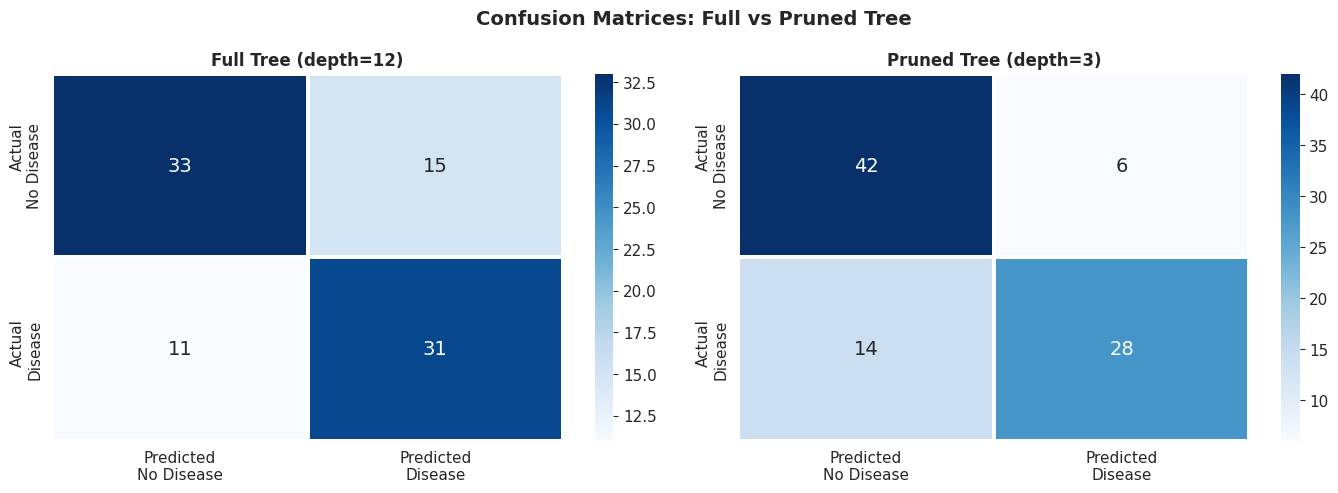


 Reading the Confusion Matrix:
   Top-Left     (TN) → Correctly predicted 'No Disease'         
   Top-Right    (FP) → Wrongly predicted 'Disease' for healthy  (Type I Error)
   Bottom-Left  (FN) → Missed a sick patient — most dangerous!  (Type II Error) 
   Bottom-Right (TP) → Correctly caught 'Heart Disease'         


In [ ]:
#  Confusion Matrices: Full Tree vs Pruned Tree side-by-side
#  Rows = ACTUAL class  |  Columns = PREDICTED class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_full,   f'Full Tree (depth={dt_full.get_depth()})'),
    (axes[1], y_pred_pruned, f'Pruned Tree (depth={best_depth})')
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted\nNo Disease', 'Predicted\nDisease'],
                yticklabels=['Actual\nNo Disease', 'Actual\nDisease'],
                linewidths=1.5, linecolor='white', annot_kws={'size': 14})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices: Full vs Pruned Tree', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Reading the Confusion Matrix:")
print("   Top-Left     (TN) → Correctly predicted 'No Disease'         ")
print("   Top-Right    (FP) → Wrongly predicted 'Disease' for healthy  (Type I Error)")
print("   Bottom-Left  (FN) → Missed a sick patient — most dangerous!  (Type II Error) ")
print("   Bottom-Right (TP) → Correctly caught 'Heart Disease'         ")

In [ ]:
#  Full Classification Report for the PRUNED tree
#  Precision, Recall, F1-Score per class

print("=" * 60)
print(" CLASSIFICATION REPORT — PRUNED TREE")
print("=" * 60)
print(classification_report(y_test, y_pred_pruned,
                             target_names=['No Disease', 'Heart Disease']))
print("\n Metric Definitions:")
print("   Precision : Of all patients predicted 'Disease', how many actually have it?")
print("   Recall    : Of all actual 'Disease' patients, how many did we correctly identify?")
print("   F1-Score  : Harmonic mean of Precision and Recall — the balanced metric")
print("   Support   : Number of actual samples per class in the test set")

 CLASSIFICATION REPORT — PRUNED TREE
               precision    recall  f1-score   support

   No Disease       0.75      0.88      0.81        48
Heart Disease       0.82      0.67      0.74        42

     accuracy                           0.78        90
    macro avg       0.79      0.77      0.77        90
 weighted avg       0.78      0.78      0.77        90


 Metric Definitions:
   Precision : Of all patients predicted 'Disease', how many actually have it?
   Recall    : Of all actual 'Disease' patients, how many did we correctly identify?
   F1-Score  : Harmonic mean of Precision and Recall — the balanced metric
   Support   : Number of actual samples per class in the test set


---
##  STEP 10 — Final Comparison: Baseline vs Full Tree vs Pruned Tree

**What are we doing here?**
From the lecture: *"Can we do better than the baseline with learning?"* Here we answer that question with numbers and a chart.

We compare three models:
1. **Baseline** — no model, just predicts the majority class every time
2. **Full Tree** — learns but overfits
3. **Pruned Tree** — learns and generalizes well

This directly demonstrates the value of both **learning** and **pruning**.

 FINAL COMPARISON TABLE
                 Model Depth Leaves Train Acc (%) Test  Acc (%) Overfit Gap
Baseline (No Learning)     —      —             —         53.33           —
  Full Tree (Unpruned)    12     47        100.00         71.11      28.89%
 Pruned Tree (depth=3)     3      7         85.99         77.78       8.21%


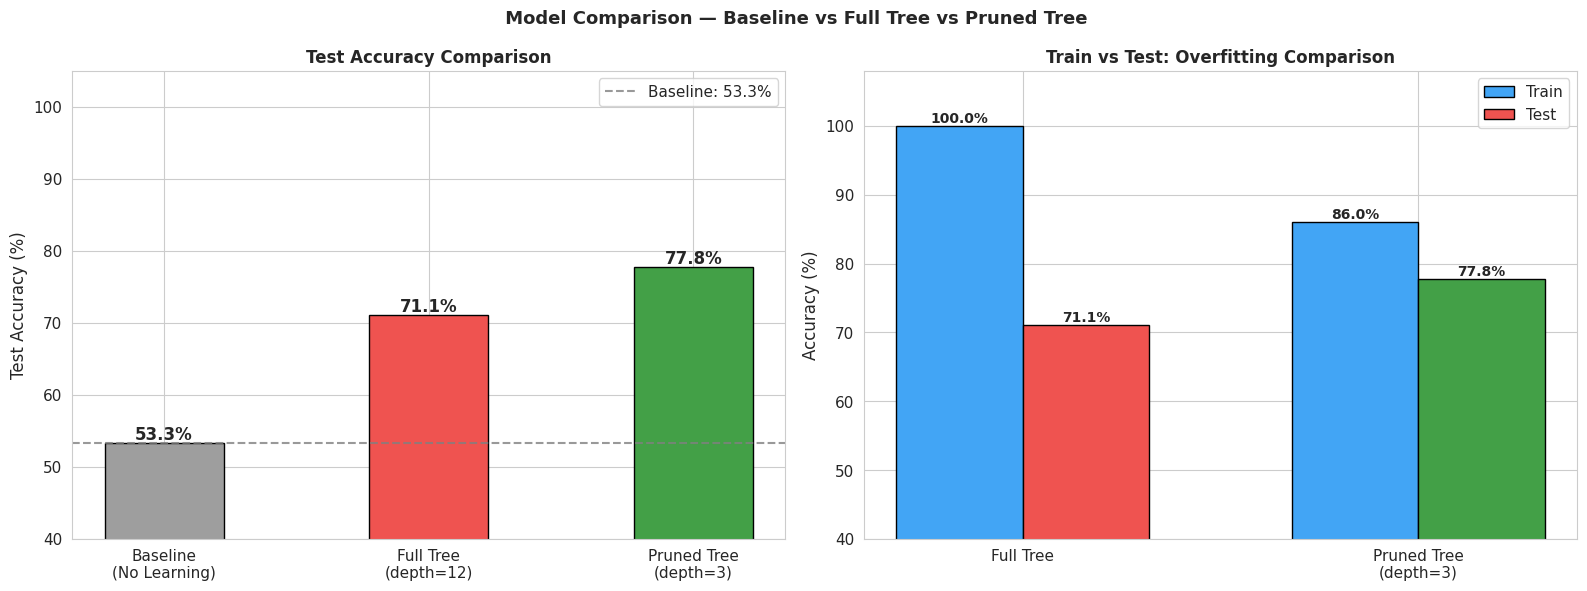


 Improvement over baseline → +24.4%
   From lecture: 'Can we do better with learning?' — YES, by 24.4 percentage points!


In [ ]:
#  Build a comparison table and bar chart for all 3 models

comparison = pd.DataFrame({
    'Model'         : ['Baseline (No Learning)', 'Full Tree (Unpruned)', f'Pruned Tree (depth={best_depth})'],
    'Depth'         : ['—',  str(dt_full.get_depth()),   str(dt_pruned.get_depth())],
    'Leaves'        : ['—',  str(dt_full.get_n_leaves()), str(dt_pruned.get_n_leaves())],
    'Train Acc (%)'  : ['—',  f'{acc_train_full:.2f}',   f'{acc_train_pruned:.2f}'],
    'Test  Acc (%)'  : [f'{baseline_acc:.2f}', f'{acc_test_full:.2f}', f'{acc_test_pruned:.2f}'],
    'Overfit Gap'   : ['—',  f'{acc_train_full-acc_test_full:.2f}%', f'{acc_train_pruned-acc_test_pruned:.2f}%'],
})

print("=" * 85)
print(" FINAL COMPARISON TABLE")
print("=" * 85)
print(comparison.to_string(index=False))

# ── Side-by-side bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test accuracy comparison
models     = ['Baseline\n(No Learning)', f'Full Tree\n(depth={dt_full.get_depth()})', f'Pruned Tree\n(depth={best_depth})']
test_vals  = [baseline_acc, acc_test_full, acc_test_pruned]
train_vals = [None, acc_train_full, acc_train_pruned]
colors_bar = ['#9E9E9E', '#EF5350', '#43A047']

bars = axes[0].bar(models, test_vals, color=colors_bar, edgecolor='black', width=0.45)
axes[0].set_ylim([40, 105])
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].axhline(baseline_acc, color='gray', linestyle='--', lw=1.5, alpha=0.8,
                label=f'Baseline: {baseline_acc:.1f}%')
axes[0].legend()
for bar, val in zip(bars, test_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Train vs Test grouped chart
x      = np.arange(2)
w      = 0.32
b1     = axes[1].bar(x - w/2, [acc_train_full,   acc_train_pruned], w,
                     label='Train', color=['#42A5F5', '#42A5F5'], edgecolor='black')
b2     = axes[1].bar(x + w/2, [acc_test_full,    acc_test_pruned],  w,
                     label='Test',  color=['#EF5350', '#43A047'], edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Full Tree', f'Pruned Tree\n(depth={best_depth})'])
axes[1].set_ylim([40, 108])
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Train vs Test: Overfitting Comparison', fontsize=12, fontweight='bold')
axes[1].legend()
for b in list(b1) + list(b2):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f'{b.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(' Model Comparison — Baseline vs Full Tree vs Pruned Tree',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

improvement = acc_test_pruned - baseline_acc
print(f"\n Improvement over baseline → +{improvement:.1f}%")
print(f"   From lecture: 'Can we do better with learning?' — YES, by {improvement:.1f} percentage points!")

---
##  STEP 11 — Predicting for New (Unseen) Patients

**What are we doing here?**
This is the **ultimate purpose** of the classification model — using it on brand new patients the model has never seen before. We give it the clinical measurements and it traverses the decision tree from root to leaf to output a prediction.

This is exactly what the lecture slides showed when tracing a test record through the tree ("Apply Model to Test Data").

In [ ]:

#  Define 4 new patients with their clinical measurements
#  We only need the TOP selected features (same as training)
#  The model will classify each one as: Heart Disease or No Disease

# Build patient records using the top selected features
# Each dict holds one patient's measurements
reference_vals = {
    'age'    : [63, 37, 41, 52],
    'sex'    : [1,  1,  0,  1 ],
    'cp'     : [3,  2,  1,  0 ],
    'trestbps': [145, 130, 130, 172],
    'chol'   : [233, 250, 204, 199],
    'fbs'    : [1,   0,   0,   1  ],
    'restecg': [0,   1,   0,   1  ],
    'thalach': [150, 187, 172, 162],
    'exang'  : [0,   0,   0,   0  ],
    'oldpeak': [2.3, 3.5, 1.4, 0.5],
    'slope'  : [0,   0,   2,   2  ],
    'ca'     : [0,   0,   0,   0  ],
    'thal'   : [1,   2,   2,   3  ],
}

new_patients_full = pd.DataFrame(reference_vals)
new_patients_full.index = ['Patient A', 'Patient B', 'Patient C', 'Patient D']

# Use only the features our model was trained on
new_patients = new_patients_full[top_features]

# ── Predict class and probability ──
predictions   = dt_pruned.predict(new_patients)
probabilities = dt_pruned.predict_proba(new_patients)

print("=" * 70)
print(" PREDICTING HEART DISEASE FOR NEW PATIENTS")
print("=" * 70)
print("\nInput features used by model:")
print(new_patients.to_string())
print("\n Predictions:")
print(f"{'Patient':<12} {'Prediction':<25} {'Confidence':>12} {'Risk Level':>12}")
print("-" * 65)
for patient, pred, prob in zip(new_patients.index, predictions, probabilities):
    label      = ' HEART DISEASE' if pred == 1 else ' NO HEART DISEASE'
    confidence = max(prob) * 100
    risk       = '  HIGH RISK' if pred == 1 else ' LOW RISK'
    print(f"{patient:<12} {label:<25} {confidence:>11.1f}% {risk:>12}")

print("\n The model traced each patient down the decision tree")
print("   from root → through branches → to a leaf node with a class label.")
print("   This is exactly the 'Apply Model to Test Data' process from the lecture!")

 PREDICTING HEART DISEASE FOR NEW PATIENTS

Input features used by model:
           thal  ca  oldpeak  cp  thalach  exang  chol
Patient A     1   0      2.3   3      150      0   233
Patient B     2   0      3.5   2      187      0   250
Patient C     2   0      1.4   1      172      0   204
Patient D     3   0      0.5   0      162      0   199

 Predictions:
Patient      Prediction                  Confidence   Risk Level
-----------------------------------------------------------------
Patient A     NO HEART DISEASE                90.3%     LOW RISK
Patient B     HEART DISEASE                  100.0%    HIGH RISK
Patient C     NO HEART DISEASE                90.3%     LOW RISK
Patient D     NO HEART DISEASE                90.3%     LOW RISK

 The model traced each patient down the decision tree
   from root → through branches → to a leaf node with a class label.
   This is exactly the 'Apply Model to Test Data' process from the lecture!


---
##  STEP 12 — Lab Summary & Key Takeaways


In [ ]:
#  Print a complete structured summary of everything we did

print("""
╔══════════════════════════════════════════════════════════════════════╗
║        CSC-411 AI — Lab Summary: Decision Tree Classification        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STEP 0 — Setup      : Imported pandas, numpy, sklearn, matplotlib   ║
║  STEP 1 — Data       : Loaded Cleveland Heart Disease CSV dataset    ║
║                         303 patients × 13 features + 1 class label   ║
║  STEP 2 — EDA        : Explored stats, missing values, class dist.   ║
║                         Visualized feature distributions by class    ║
║  STEP 3 — Feature    : Ranked features using 3 methods:              ║
║           Selection    1) Pearson Correlation with target            ║
║                        2) Mutual Information (= Info Gain!)          ║
║                        3) Decision Tree importance                   ║
║                        → Selected TOP 7 features                     ║
║  STEP 4 — Feature    : Used PCA to compress 13 features to 2D        ║
║           Extraction   to visualize class separation                 ║
║  STEP 5 — Entropy &  : Manually calculated entropy and Info Gain     ║
║           Info Gain    for every feature using lecture formulas      ║
║                        Identified the ROOT node attribute            ║
║  STEP 6 — Split      : 70% training / 30% testing (stratified)       ║
║  STEP 7 — Full Tree  : Built unpruned tree → overfitting observed    ║
║  STEP 8 — Pruning    : Swept depths 1–15, found optimal depth        ║
║                        Built pruned tree → lower overfit gap         ║
║  STEP 9 — Evaluate   : Confusion matrix, precision, recall, F1       ║
║  STEP 10 — Compare   : Pruned > Full > Baseline (proved learning!)   ║
║  STEP 11 — Predict   : Classified 4 brand new patients               ║
║                                                                      ║
║  KEY CONCEPTS FROM LECTURE (connected to code):                      ║
║  • entropy(D) = -Σ Pr(cj) log₂ Pr(cj)  → impurity of a node          ║
║  • Info Gain  = parent entropy - child weighted entropy              ║
║  • Split on the feature with HIGHEST Information Gain                ║
║  • Full tree = overfitting  |  Pruning = better generalization       ║
║  • accuracy = correct predictions / total test cases                 ║
╚══════════════════════════════════════════════════════════════════════╝
""")
print(f"  Baseline (no learning)  : {baseline_acc:.1f}%  — always predicts majority class")
print(f"  Full Tree (unpruned)    : {acc_test_full:.1f}%  — learns but overfits")
print(f"  Pruned Tree (depth={best_depth})  : {acc_test_pruned:.1f}%  — best balance ✅")
print(f"\n  Improvement from learning: +{acc_test_pruned - baseline_acc:.1f}%")
print("\n   Lab Complete — Great work!")


╔══════════════════════════════════════════════════════════════════════╗
║        CSC-411 AI — Lab Summary: Decision Tree Classification        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STEP 0 — Setup      : Imported pandas, numpy, sklearn, matplotlib   ║
║  STEP 1 — Data       : Loaded Cleveland Heart Disease CSV dataset    ║
║                         303 patients × 13 features + 1 class label   ║
║  STEP 2 — EDA        : Explored stats, missing values, class dist.   ║
║                         Visualized feature distributions by class    ║
║  STEP 3 — Feature    : Ranked features using 3 methods:              ║
║           Selection    1) Pearson Correlation with target            ║
║                        2) Mutual Information (= Info Gain!)          ║
║                        3) Decision Tree importance                   ║
║                        → Selected TOP 7 features